In [2]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, cohen_kappa_score
from datetime import datetime, date, timedelta
import torch

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
print(module_path)

from explainability_analysis.crop_spectral_signature_analysis import *
from explainability_analysis.visualization_constants import *
from datasets import sequence_aggregator

# import torchsummary

# module_path = os.path.abspath(os.path.join('..'))
# if module_path not in sys.path:
#     sys.path.append(module_path)

# from models.CropTypeClassifier import *
# from explainability_analysis.visualization_constants import *
# from explainability_analysis.visualization_functions import *
# from explainability_analysis.classification_results_summarizer import read_confusion_matrix

tex_fonts_false = {
    #source: https://jwalton.info/Embed-Publication-Matplotlib-Latex/
    # Use LaTeX to write all text
    "text.usetex": False,               # --> tex package not found
    "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
    #"axes.labelsize": 10,
    "font.size": 10,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 8,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    'text.latex.preamble': r"\usepackage{amsmath}"
}

plt.rcParams.update(tex_fonts_false)


/home/luca/luca_docker/crop-type-classification-explainability


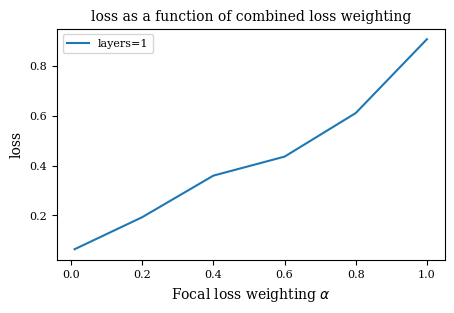

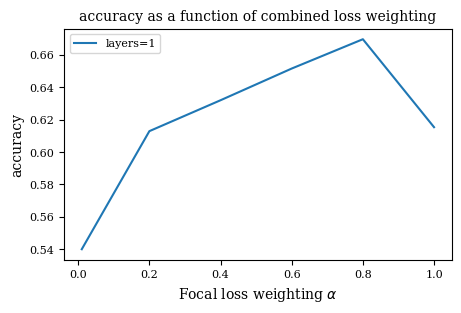

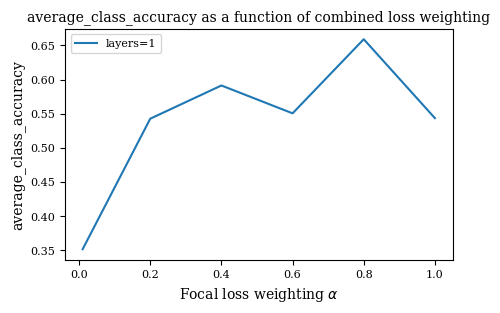

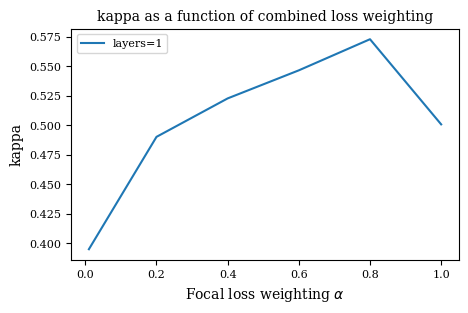

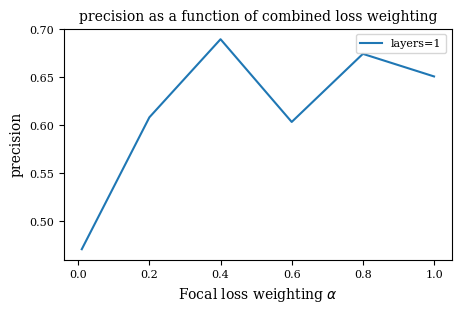

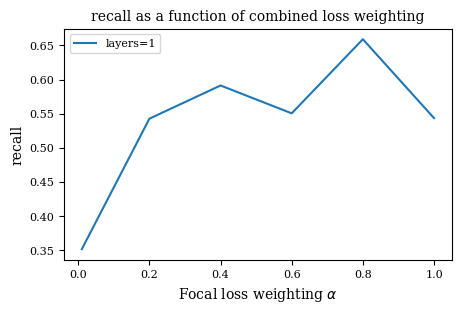

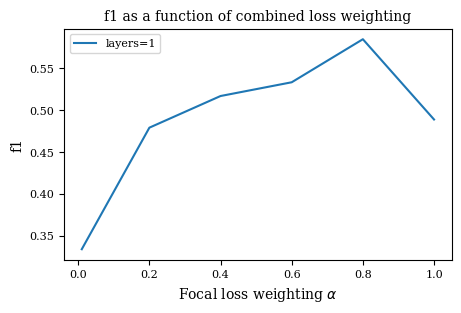

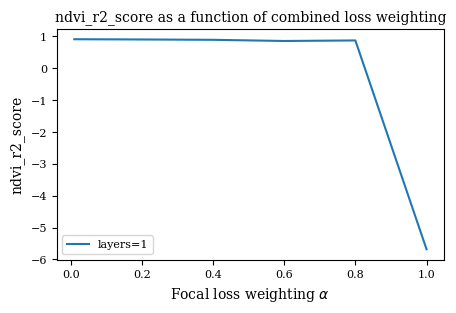

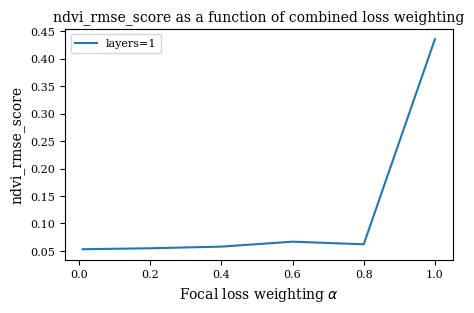

In [2]:
# Viz metrics as f(alpha)
focal_loss_weights = [1, 20, 40, 60, 80, 100]
layers = [1]#,3,5]
heads = [1]#,2,4]#,8,16]
metric_keys = ['loss','accuracy','average_class_accuracy','kappa','precision','recall','f1','ndvi_r2_score','ndvi_rmse_score']

all_metrics = np.zeros((len(layers), len(heads), len(focal_loss_weights), len(metric_keys)))

res_dir = "/home/luca/luca_docker/results/crop-type-classification-explainability/9_classes/tae/right_padding/obs_aq_date/"

for l, layer in enumerate(layers):
    for h, head in enumerate(heads):
        for i, weight in enumerate(focal_loss_weights):
            preds_path = os.path.join(res_dir, f'layers={layer},heads={head},emb_dim=128', 'rmse', f'focal_loss_ratio={weight}', 'all_dates')
            
            if os.path.exists(preds_path):
                timestamp = os.listdir(preds_path)[0]
                preds_path = os.path.join(preds_path, timestamp)
                classm_path = os.path.join(preds_path, "predictions", 'classification_metrics.csv')
                ndvim_path = os.path.join(preds_path, "predictions", 'ndvi_metrics.csv')

                csv_file = pd.read_csv(classm_path)
                csv_file1 = pd.read_csv(ndvim_path)

                csv_file['ndvi_r2_score'] = csv_file1['ndvi_r2_score']
                csv_file['ndvi_rmse_score'] = csv_file1['ndvi_rmse_score']

                for k, key in enumerate(metric_keys):
                    all_metrics[l, h, i, k] = csv_file.iloc[0][key]
            else:
                print(f'{preds_path} not found. Set metric values to 0.')
                for k, key in enumerate(metric_keys):
                    all_metrics[l, h, i, k] = 0.0
    
layer_labels = [f'layers={str(l)}' for l in layers]
focal_loss_weights_ratio = [w/100 for w in focal_loss_weights]

save_imgs = os.path.join(res_dir, 'plots')
os.makedirs(save_imgs, exist_ok=True)

# print(all_metrics[0,0,:,8])

# Plots:
for k, key in enumerate(metric_keys):
    fig = plt.figure(figsize=(5,3))
    for i, llab in enumerate(layer_labels):
        plt.plot(focal_loss_weights_ratio, all_metrics[i, 0, :, k], label=llab)
        plt.title(f'{key} as a function of combined loss weighting')
        plt.xlabel(r'Focal loss weighting $\alpha$')
        plt.ylabel(key)
        plt.legend()
        plt.savefig(os.path.join(save_imgs, f'{key}_heads.png'))
    plt.show()


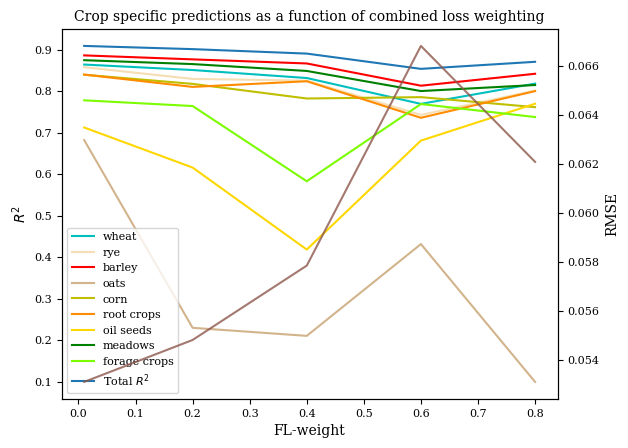

In [ ]:
# Viz individual performances of crops as f(a):
res_dir = r"/home/luca/luca_docker/results/crop-type-classification-explainability/9_classes/tae/right_padding/obs_aq_date/layers=1,heads=1,emb_dim=128/rmse"
save_imgs = os.path.join(res_dir, 'plots')
os.makedirs(save_imgs, exist_ok=True)

dataset = 'DENETHOR'
if dataset == 'BavarianCrops':
    target_classes = ["grassland", "corn", "summer barley", "winter barley", "winter wheat", "fallow"]
else:
    target_classes = ["wheat", "rye", "barley", "oats", "corn", "root crops", "oil seeds", "meadows", "forage crops"]

focal_loss_weights = [1, 20, 40, 60, 80]#, 100]

results_list = []
for i, alpha in enumerate(focal_loss_weights):
    preds_path = os.path.join(res_dir, f'focal_loss_ratio={alpha}', 'all_dates')
            
    if os.path.exists(preds_path):
        timestamp = os.listdir(preds_path)[-1]
        preds_path = os.path.join(preds_path, timestamp)
        preds_path = os.path.join(preds_path, "predictions", 'ndvi_metrics.csv')

        alpha_df = pd.read_csv(preds_path)
        alpha_df['FL-weight'] = alpha/100
        results_list.append(alpha_df)

ndvi_results = pd.concat(results_list)
ndvi_crops = ndvi_results[target_classes + ['FL-weight']].melt('FL-weight', var_name='Crop type', value_name='$R^2$')

fig = plt.figure()
axs = sns.lineplot(data=ndvi_crops, x="FL-weight", y='$R^2$', hue='Crop type', palette=CROP_TYPE_COLOR_MAPPING, legend='auto')
axs.plot(ndvi_results['FL-weight'].values, ndvi_results['ndvi_r2_score'].values, c='tab:blue', label='Total $R^2$')
plt.legend()
axs_twin = axs.twinx()
axs_twin.plot(ndvi_results['FL-weight'].values, ndvi_results['ndvi_rmse_score'].values, c='tab:brown', alpha=0.8)
axs_twin.set_ylabel('RMSE')
plt.title('Crop specific predictions as a function of combined loss weighting')
plt.savefig(os.path.join(save_imgs, f'r2_per_crop_full.png'))
plt.show()


Initializing BavarianCropsDataset train partition in holl
read 12 classes
precached dataset files found at /home/luca/luca_docker/datasets/BavarianCrops/npy/12_classes/blocks/holl/train
Dataset /home/luca/luca_docker/datasets/BavarianCrops. region holl. partition train.X:20858x(71, 16), y:(20858,) with 12 classes
Initializing BavarianCropsDataset valid partition in holl
read 12 classes
precached dataset files found at /home/luca/luca_docker/datasets/BavarianCrops/npy/12_classes/blocks/holl/valid
Dataset /home/luca/luca_docker/datasets/BavarianCrops. region holl. partition valid.X:3909x(144, 16), y:(3909,) with 12 classes
Initializing BavarianCropsDataset test partition in holl
read 12 classes
precached dataset files found at /home/luca/luca_docker/datasets/BavarianCrops/npy/12_classes/blocks/holl/test
Dataset /home/luca/luca_docker/datasets/BavarianCrops. region holl. partition test.X:9583x(144, 16), y:(9583,) with 12 classes
Initializing BavarianCropsDataset train partition in krum
re

<Axes: xlabel='Date', ylabel='NDVI'>

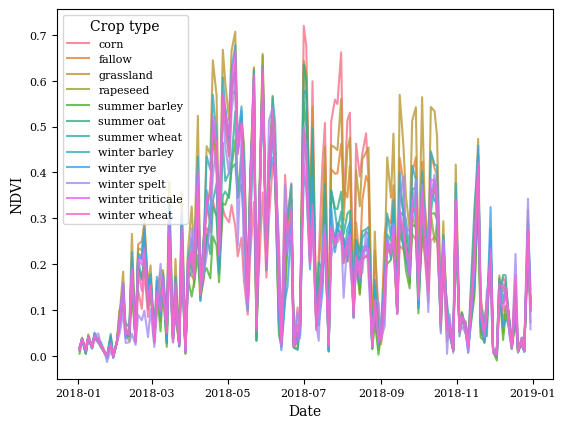

In [2]:
# Load NDVI - ground truth
dataset = 'BavarianCrops'
spectral_indices = get_dataset_spectral_indices(dataset=dataset)
avg_ndvi_time_series = spectral_indices.groupby(['Crop type', 'Date'])['NDVI'].mean().reset_index()
cropsvar_ndvi_time_series = avg_ndvi_time_series.groupby('Date')['NDVI'].var().sort_index()

sns.lineplot(data=avg_ndvi_time_series, x='Date', y='NDVI', hue='Crop type', alpha=0.8)

In [4]:
if dataset == 'BavarianCrops':
    train_set, valid_set, test_set = dataset_utils.get_partitioned_dataset_BavarianCrops("/home/luca/luca_docker/datasets/BavarianCrops", "/home/luca/luca_docker/datasets/BavarianCrops/classmapping12.csv", sequence_aggregator.SequencePadder(), classes_to_exclude=None)
else:
    train_set, valid_set, test_set = dataset_utils.get_partitioned_dataset_DenethorS2("/home/luca/luca_docker/datasets/DENETHOR", "/home/luca/luca_docker/datasets/DENETHOR/classmapping9.csv", sequence_aggregator.SequencePadder(), classes_to_exclude=None)

Initializing BavarianCropsDataset train partition in holl
read 12 classes
precached dataset files found at /home/luca/luca_docker/datasets/BavarianCrops/npy/12_classes/blocks/holl/train
Dataset /home/luca/luca_docker/datasets/BavarianCrops. region holl. partition train.X:20858x(71, 16), y:(20858,) with 12 classes
Initializing BavarianCropsDataset valid partition in holl
read 12 classes
precached dataset files found at /home/luca/luca_docker/datasets/BavarianCrops/npy/12_classes/blocks/holl/valid
Dataset /home/luca/luca_docker/datasets/BavarianCrops. region holl. partition valid.X:3909x(144, 16), y:(3909,) with 12 classes
Initializing BavarianCropsDataset test partition in holl
read 12 classes
precached dataset files found at /home/luca/luca_docker/datasets/BavarianCrops/npy/12_classes/blocks/holl/test
Dataset /home/luca/luca_docker/datasets/BavarianCrops. region holl. partition test.X:9583x(144, 16), y:(9583,) with 12 classes
Initializing BavarianCropsDataset train partition in krum
re

In [ ]:
from sklearn.metrics import root_mean_squared_error
# path to model: h=1,FL=0.8
ndvi_preds_path = "/home/luca/luca_docker/results/crop-type-classification-explainability/9_classes/tae/right_padding/obs_aq_date/layers=1,heads=1,emb_dim=128/rmse/focal_loss_ratio=80/all_dates/1739561368/predictions/ndvi_predictions.json"
# crop_types = ['corn', 'summer barley', 'winter barley']#,'grassland', 'fallow', 'winter wheat']
crop_types = ["corn", "barley", "wheat"]#,'grassland', 'fallow', 'winter wheat']

# healthy_veg_samples = get_top_NDVI_obs_per_parcel(spectral_indices)
# healthy_veg_curve = get_average_spectral_reflectance_curve(spectral_indices)
# print(healthy_veg_curve)


# Extracting both NDVI and NDVI predictions and plotting comparison
def get_ndvi_predictions(data):
    ndvi_preds = pd.DataFrame(columns=['Parcel ID', 'Crop type', 'Date', 'NDVI', 'NDVI pred'])
    
    for sample_id, (crop_type, ndvi_timeseries, prediction_timeseries) in data.items():
        
        test_idx = test_set.ids.index(int(sample_id))  
        X, positions, y, y_ndvi, parcel_id = test_set.__getitem__(test_idx)
               
        strt_date = date(STARTING_TEST_DATE.year, 1, 1) #STARTING_ACQUISITION_DATE
        for i,doy in enumerate(positions):
            if doy != -1:
                res_date = strt_date + timedelta(days=int(doy) - 1)
                ndvi_date = res_date.strftime("%Y-%m-%d")
                ndvi_preds.loc[i] = [sample_id, crop_type, ndvi_date, ndvi_timeseries[i], prediction_timeseries[i]]

    return ndvi_preds


with open(ndvi_preds_path) as f:
    data = json.load(f)

ndvi_preds = get_ndvi_predictions(data)
# ndvi_preds['Date'] = pd.to_datetime(ndvi_preds['Date'])

# Plotting the comparison between NDVI and NDVI predictions for each crop
fig, axes = plt.subplots(len(crop_types), 1, figsize=(8, 6), sharex=True)
plt.suptitle(r'Comparison of Actual and Predicted crop-averaged NDVI - $\alpha$=0.8')
for ax, crop in zip(axes, crop_types):
    crop_ndvi = ndvi_preds[ndvi_preds["Crop type"] == crop][['Date', 'NDVI', 'NDVI pred']]
    avg_ndvi_per_crop = crop_ndvi.groupby('Date').mean().set_index('Date')

    print(crop_ndvi)
    print(root_mean_squared_error(crop_ndvi['NDVI'].values, crop_ndvi['NDVI pred']))
    
    ax.plot(avg_ndvi_time_series['Date'].values, avg_ndvi_time_series['NDVI'].values, label=f'Average NDVI ({crop})', color='mediumblue', linestyle = '--', alpha=0.8)
    ax.plot(avg_ndvi_per_crop.index.values, avg_ndvi_per_crop['NDVI pred'].values, label=f'Predicted NDVI ({crop})', color=CROP_TYPE_COLOR_MAPPING[crop])
    ax.plot(avg_ndvi_per_crop.index.values, avg_ndvi_per_crop['NDVI'].values, label=f'Predicted NDVI ({crop})', color=CROP_TYPE_COLOR_MAPPING[crop])
    # ax.set_title(crop)
    ax.set_ylabel('NDVI')
    ax.legend()

axes[-1].set_xlabel('Date')
axes[-1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()



AttributeError: 'ConcatDataset' object has no attribute '__getids'

In [80]:
ndvi_preds

,Parcel ID,Crop type,Date,NDVI,NDVI pred
0,90770,corn,2019-01-13,0.229924,0.168537
1,90770,corn,2019-01-18,0.150905,0.134689
2,90770,corn,2019-01-21,0.108414,0.201896
3,90770,corn,2019-02-05,0.213441,0.166919
4,90770,corn,2019-02-07,0.217242,0.184165
...,...,...,...,...,...
77,92596,corn,2019-12-19,0.473714,0.508618
78,151163,corn,2019-12-19,0.248873,0.211639
79,151163,corn,2019-12-27,0.051140,-0.072735
80,149584,oil seeds,2019-12-17,0.168887,0.163858


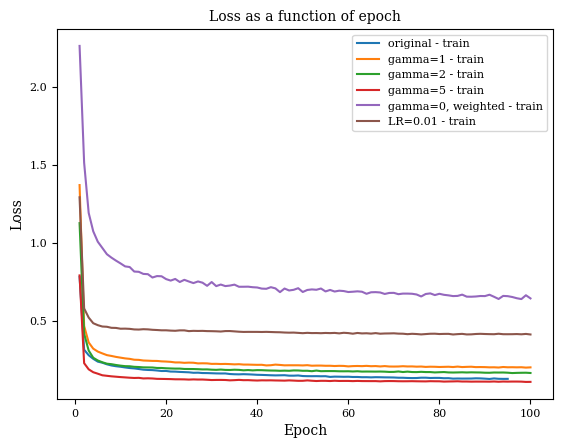

In [4]:
tmstps = ['1741358930', '1743704776', '1745503460', '1745580721', '1745750760', '1745852478']
labels = ['original', 'gamma=1', 'gamma=2', 'gamma=5', 'gamma=0, weighted', 'LR=0.01']

path_to_mdl = "/home/luca/luca_docker/results/crop-type-classification-explainability/12_classes/ltae/right_padding/obs_aq_date/layers=1,heads=16,emb_dim=128/rmse/focal_loss_ratio=100/all_dates"

for i, tmstp in enumerate(tmstps):
    preds_path = os.path.join(path_to_mdl, tmstp)
    logger = pd.read_csv(os.path.join(preds_path, "log.csv"))

    log_train = logger[logger['mode'] == 'train']
    # log_test = logger[logger['mode'] == 'test']
    
    plt.plot(log_train['epoch'], log_train['loss'], label=labels[i]+' - train')
    # plt.plot(log_test['epoch'], log_test['loss'], label=labels[i]+' - test')

plt.title('Loss as a function of epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()